<a href="https://colab.research.google.com/github/xqrnz/Exploring-NYC-Public-School-Test-Result-Scores/blob/main/nyc_schools_sat_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Exploring NYC Public School SAT Performance

> **DataCamp Project | Portfolio Edition**  
> *Expanded & Annotated by Esmael Yasin
— GitHub: [qylpx](https://github.com/xqrnz)*

---

##  Project Overview

Every year, **SAT scores** play a critical role in college admissions for millions of students across the United States. In New York City — one of the most educationally diverse cities in the world — public school performance varies dramatically across boroughs, school types, and neighborhoods.

This project uses **real standardized test data** from NYC public high schools to:

| Goal | Description |
|------|-------------|
|  Identify top math schools | Schools where average math SAT ≥ 640 (80% of max 800) |
|  Rank top 10 schools | Based on combined SAT score (Math + Reading + Writing) |
|  Borough analysis | Which NYC borough has the highest SAT score variability? |

---

##  Dataset Description

The dataset (`schools.csv`) contains SAT performance data for NYC public high schools.

| Column | Description |
|--------|-------------|
| `school_name` | Full name of the school |
| `borough` | NYC borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `building_code` | Unique building identifier |
| `average_math` | Average SAT Math score (max: 800) |
| `average_reading` | Average SAT Reading score (max: 800) |
| `average_writing` | Average SAT Writing score (max: 800) |
| `percent_tested` | % of students who sat the SAT |

**Total possible SAT score: 2400** (800 × 3 sections)

---

##  Tools & Libraries

- **Python 3** — core language
- **pandas** — data manipulation and analysis
- **matplotlib / seaborn** — data visualization
- **numpy** — numerical operations

---

##  Step 1: Import Libraries & Load Data

We start by importing all the libraries we'll need for the full analysis.

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)       # Show all columns
pd.set_option('display.max_colwidth', 60)        # Limit column text width
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


In [2]:
# Load the dataset
schools = pd.read_csv('/content/schools.csv')

print(f'Dataset shape: {schools.shape[0]} schools × {schools.shape[1]} columns')
schools.head(10)

Dataset shape: 375 schools × 7 columns


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and Math High ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.90
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.10
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.90
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.70
5,Bard High School Early College,Manhattan,M097,634,641,639,70.80
6,Urban Assembly Academy of Government and Law,Manhattan,M445,389,395,381,80.80
7,Marta Valle High School,Manhattan,M025,438,413,394,35.60
8,University Neighborhood High School,Manhattan,M446,437,355,352,69.90
9,New Design High School,Manhattan,M445,381,396,372,73.70


---

##  Step 2: Exploratory Data Analysis (EDA)

Before solving any specific question, a good data scientist always **explores the data** first.
This helps us understand:
- What does the data look like?
- Are there missing values?
- What is the distribution of scores?
- Are there any outliers?

In [3]:
# --- Basic Info ---
print('=== DATASET INFO ===')
schools.info()
print()

# --- Summary statistics ---
print('=== SUMMARY STATISTICS ===')
schools.describe()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_name      375 non-null    object 
 1   borough          375 non-null    object 
 2   building_code    375 non-null    object 
 3   average_math     375 non-null    int64  
 4   average_reading  375 non-null    int64  
 5   average_writing  375 non-null    int64  
 6   percent_tested   355 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 20.6+ KB

=== SUMMARY STATISTICS ===


,average_math,average_reading,average_writing,percent_tested
count,375.00,375.00,375.00,355.00
mean,432.94,424.50,418.46,64.98
std,71.95,61.88,64.55,18.75
min,317.00,302.00,284.00,18.50
25%,386.00,386.00,382.00,50.95
50%,415.00,413.00,403.00,64.80
75%,458.50,445.00,437.50,79.60
max,754.00,697.00,693.00,100.00


In [5]:
# --- Missing values ---
print('=== MISSING VALUES ===')
missing = schools.isnull().sum()
missing_pct = (missing / len(schools) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])

=== MISSING VALUES ===
                missing_count  missing_%
percent_tested             20       5.33


=== SCHOOLS PER BOROUGH ===
borough
Brooklyn         109
Bronx             98
Manhattan         89
Queens            69
Staten Island     10


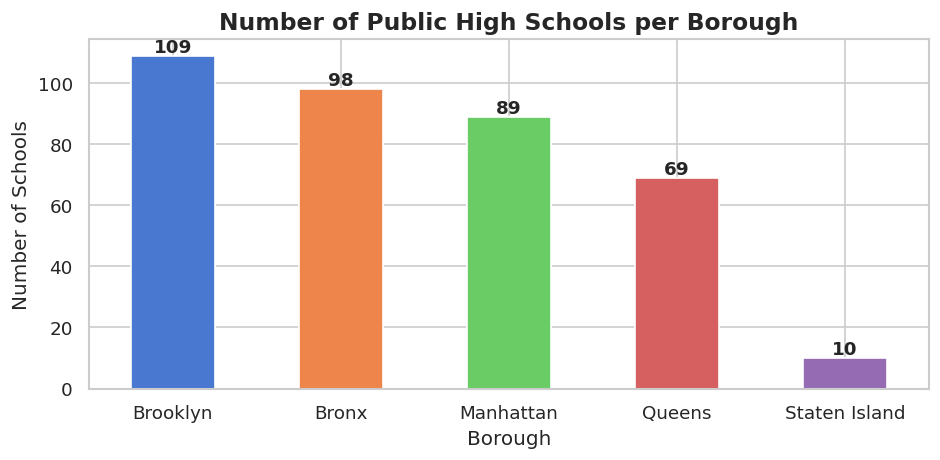

In [6]:
# --- Schools per borough ---
print('=== SCHOOLS PER BOROUGH ===')
borough_counts = schools['borough'].value_counts()
print(borough_counts.to_string())

# Quick bar chart
fig, ax = plt.subplots(figsize=(8, 4))
borough_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 5), edgecolor='white')
ax.set_title('Number of Public High Schools per Borough', fontsize=14, fontweight='bold')
ax.set_xlabel('Borough')
ax.set_ylabel('Number of Schools')
ax.set_xticklabels(borough_counts.index, rotation=0)
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

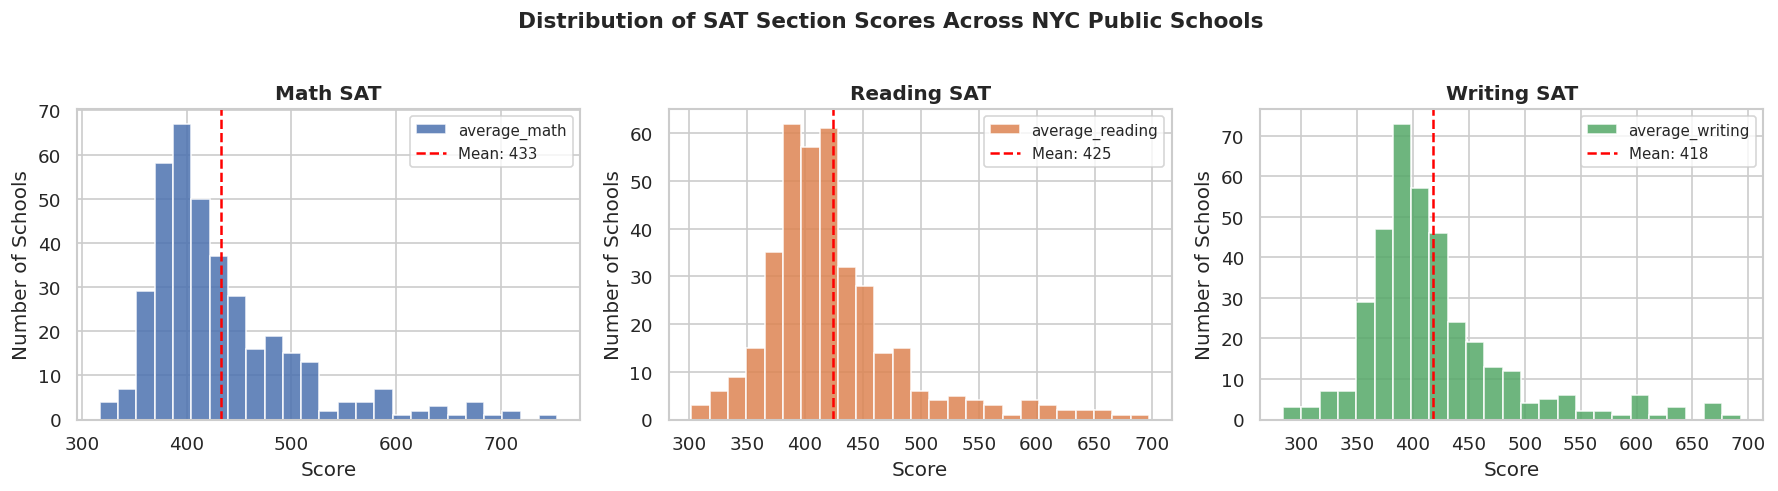


 Observation: All three SAT sections show a roughly right-skewed distribution.
   A few elite schools pull the averages up — the median is more representative.


In [8]:
# --- SAT Score Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sections = ['average_math', 'average_reading', 'average_writing']
titles = ['Math SAT', 'Reading SAT', 'Writing SAT']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, title, color in zip(axes, sections, titles, colors):
    schools[col].dropna().plot(kind='hist', bins=25, ax=ax, color=color,
                               edgecolor='white', alpha=0.85)
    ax.axvline(schools[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {schools[col].mean():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Schools')
    ax.legend(fontsize=9)

fig.suptitle('Distribution of SAT Section Scores Across NYC Public Schools',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n Observation: All three SAT sections show a roughly right-skewed distribution.')
print('   A few elite schools pull the averages up — the median is more representative.')

---

## Step 3: Which Schools Have the Best Math Results?

###  Logic

The maximum possible SAT Math score is **800**.  
We define "best math results" as scoring at least **80% of 800 = 640**.

This threshold represents schools where the **average student** is performing at a high level — not just individual top performers.

###  Approach
1. Filter rows where `average_math >= 640`
2. Keep only `school_name` and `average_math` columns
3. Sort descending by `average_math`

In [9]:
# --- Best Math Schools ---
# Threshold: 80% of max score (800) = 640
MATH_THRESHOLD = 800 * 0.80  # = 640

best_math_schools = (
    schools[schools['average_math'] >= MATH_THRESHOLD]
    [['school_name', 'average_math']]
    .sort_values('average_math', ascending=False)
    .reset_index(drop=True)
)

best_math_schools.index += 1  # Start rank from 1

print(f' {len(best_math_schools)} schools meet the 80% math threshold (≥ {int(MATH_THRESHOLD)})')
print()
best_math_schools

 10 schools meet the 80% math threshold (≥ 640)



,school_name,average_math
1,Stuyvesant High School,754
2,Bronx High School of Science,714
3,Staten Island Technical High School,711
4,Queens High School for the Sciences at York College,701
5,"High School for Mathematics, Science, and Engineering at...",683
6,Brooklyn Technical High School,682
7,Townsend Harris High School,680
8,High School of American Studies at Lehman College,669
9,"New Explorations into Science, Technology and Math High ...",657
10,Eleanor Roosevelt High School,641


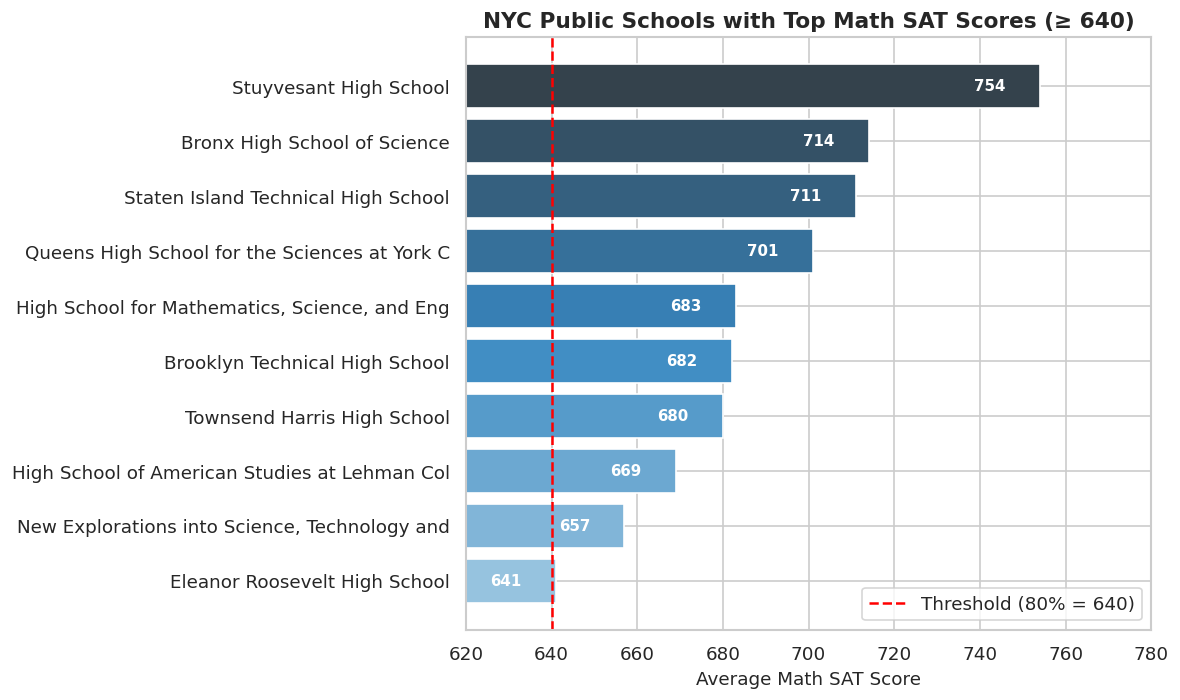


 Stuyvesant High School leads by a wide margin — it is a specialized school
   requiring a competitive entrance exam (SHSAT).


In [10]:
# --- Visualization: Top Math Schools ---
fig, ax = plt.subplots(figsize=(10, 6))

# Shorten long names for display
display_names = best_math_schools['school_name'].str.slice(0, 45)

bars = ax.barh(display_names[::-1], best_math_schools['average_math'][::-1],
               color=sns.color_palette('Blues_d', len(best_math_schools)))

# Threshold line
ax.axvline(MATH_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (80% = {int(MATH_THRESHOLD)})')

# Score labels
for bar in bars:
    ax.text(bar.get_width() - 8, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width())}',
            va='center', ha='right', color='white', fontweight='bold', fontsize=9)

ax.set_xlabel('Average Math SAT Score', fontsize=11)
ax.set_title('NYC Public Schools with Top Math SAT Scores (≥ 640)', fontsize=13, fontweight='bold')
ax.set_xlim(620, 780)
ax.legend()
plt.tight_layout()
plt.show()

print('\n Stuyvesant High School leads by a wide margin — it is a specialized school')
print('   requiring a competitive entrance exam (SHSAT).')

---

##  Step 4: Top 10 Schools by Combined SAT Score

###  Logic

The **total SAT score** is the sum of all three sections:

$$\text{total\_SAT} = \text{average\_math} + \text{average\_reading} + \text{average\_writing}$$

Maximum possible = **2400**

###  Approach
1. Create a new column `total_SAT`
2. Sort all schools by `total_SAT` descending
3. Take the top 10

In [11]:
# --- Compute Total SAT ---
schools['total_SAT'] = schools['average_math'] + schools['average_reading'] + schools['average_writing']

# --- Top 10 schools ---
top_10_schools = (
    schools
    .sort_values('total_SAT', ascending=False)
    [['school_name', 'borough', 'total_SAT', 'average_math', 'average_reading', 'average_writing']]
    .head(10)
    .reset_index(drop=True)
)

top_10_schools.index += 1  # Rank from 1

# Add percentage of max score
top_10_schools['% of max (2400)'] = (top_10_schools['total_SAT'] / 2400 * 100).round(1).astype(str) + '%'

print(' Top 10 NYC Public Schools by Total SAT Score')
top_10_schools

 Top 10 NYC Public Schools by Total SAT Score


,school_name,borough,total_SAT,average_math,average_reading,average_writing,% of max (2400)
1,Stuyvesant High School,Manhattan,2144,754,697,693,89.3%
2,Bronx High School of Science,Bronx,2041,714,660,667,85.0%
3,Staten Island Technical High School,Staten Island,2041,711,660,670,85.0%
4,High School of American Studies at Lehman College,Bronx,2013,669,672,672,83.9%
5,Townsend Harris High School,Queens,1981,680,640,661,82.5%
6,Queens High School for the Sciences at York College,Queens,1947,701,621,625,81.1%
7,Bard High School Early College,Manhattan,1914,634,641,639,79.8%
8,Brooklyn Technical High School,Brooklyn,1896,682,608,606,79.0%
9,Eleanor Roosevelt High School,Manhattan,1889,641,617,631,78.7%
10,"High School for Mathematics, Science, and Engineering at...",Manhattan,1889,683,610,596,78.7%


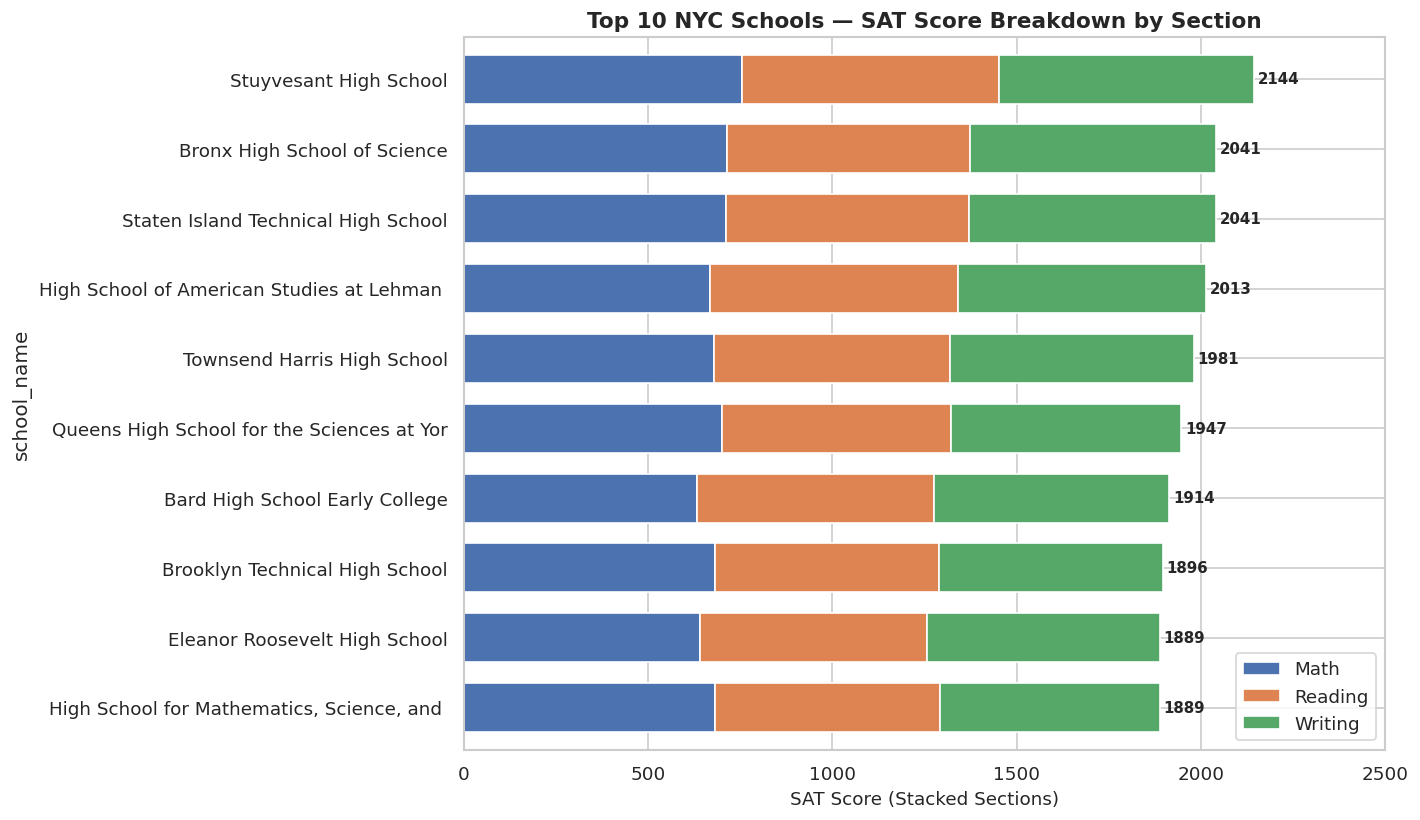


 Stuyvesant, Bronx Science, and Brooklyn Tech dominate — all specialized schools.
   Non-specialized schools like Townsend Harris and Staten Island Tech also rank highly.


In [12]:
# --- Stacked Bar Chart: Score Breakdown for Top 10 ---
plot_data = top_10_schools[['school_name', 'average_math', 'average_reading', 'average_writing']].copy()
plot_data['school_name'] = plot_data['school_name'].str.slice(0, 42)  # Truncate for display
plot_data = plot_data.set_index('school_name')

fig, ax = plt.subplots(figsize=(12, 7))
plot_data.iloc[::-1].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='white', width=0.7
)

ax.set_xlabel('SAT Score (Stacked Sections)', fontsize=11)
ax.set_title('Top 10 NYC Schools — SAT Score Breakdown by Section', fontsize=13, fontweight='bold')
ax.legend(['Math', 'Reading', 'Writing'], loc='lower right')
ax.set_xlim(0, 2500)

# Add total labels
for i, (idx, row) in enumerate(plot_data.iloc[::-1].iterrows()):
    total = row.sum()
    ax.text(total + 10, i, f'{int(total)}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Stuyvesant, Bronx Science, and Brooklyn Tech dominate — all specialized schools.')
print('   Non-specialized schools like Townsend Harris and Staten Island Tech also rank highly.')

---

##  Step 5: Which Borough Has the Highest SAT Score Variability?

###  Logic

**Standard deviation** measures how spread out SAT scores are within a borough.  
A **high std dev** = wide performance gap between schools in that borough (some very high, some very low).  
A **low std dev** = schools in that borough perform more consistently.

This is important because **high variability** can signal inequality — strong elite schools alongside struggling ones.

### Approach
1. Group by `borough`
2. Aggregate: count, mean, std of `total_SAT`
3. Filter for the borough with maximum std deviation
4. Rename and clean up the result

In [13]:
# --- Borough-level aggregation ---
boroughs = (
    schools
    .groupby('borough')['total_SAT']
    .agg(['count', 'mean', 'std'])
    .round(2)
)

# Rename columns for clarity
boroughs.columns = ['num_schools', 'average_SAT', 'std_SAT']

print('=== SAT Summary by Borough ===')
boroughs.sort_values('std_SAT', ascending=False)

=== SAT Summary by Borough ===


,num_schools,average_SAT,std_SAT
borough,,,
Manhattan,89,1340.13,230.29
Staten Island,10,1439.00,222.30
Queens,69,1345.48,195.25
Brooklyn,109,1230.26,154.87
Bronx,98,1202.72,150.39


In [14]:
# --- Borough with highest std dev (answer to Q3) ---
largest_std_dev = (
    boroughs[boroughs['std_SAT'] == boroughs['std_SAT'].max()]
    .reset_index()  # Make 'borough' a regular column
)

print(' Borough with Highest SAT Score Variability:')
largest_std_dev

 Borough with Highest SAT Score Variability:


,borough,num_schools,average_SAT,std_SAT
0,Manhattan,89,1340.13,230.29


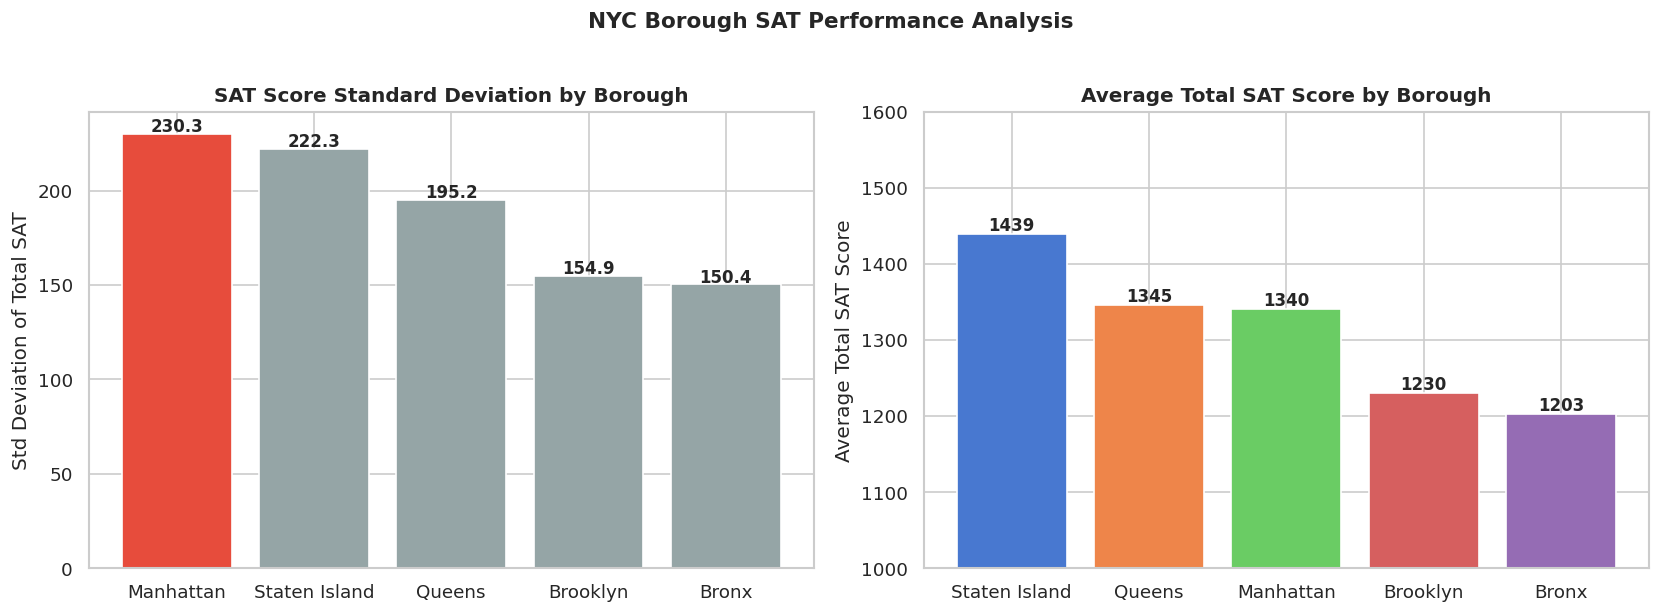


 Manhattan has the highest std deviation (230.29),
   reflecting its extremes: elite schools like Stuyvesant alongside
   under-resourced schools in the same borough.


In [16]:
# --- Visualization: Std Dev Comparison Across Boroughs ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

borough_plot = boroughs.sort_values('std_SAT', ascending=False).reset_index()

# Chart 1: Standard deviation
colors_std = ['#e74c3c' if b == largest_std_dev['borough'].values[0] else '#95a5a6'
              for b in borough_plot['borough']]
bars1 = axes[0].bar(borough_plot['borough'], borough_plot['std_SAT'],
                    color=colors_std, edgecolor='white')
axes[0].set_title('SAT Score Standard Deviation by Borough', fontweight='bold')
axes[0].set_ylabel('Std Deviation of Total SAT')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

# Chart 2: Average SAT by Borough
borough_plot2 = boroughs.sort_values('average_SAT', ascending=False).reset_index()
bars2 = axes[1].bar(borough_plot2['borough'], borough_plot2['average_SAT'],
                    color=sns.color_palette('muted', 5), edgecolor='white')
axes[1].set_title('Average Total SAT Score by Borough', fontweight='bold')
axes[1].set_ylabel('Average Total SAT Score')
axes[1].set_ylim(1000, 1600)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{bar.get_height():.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('NYC Borough SAT Performance Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Manhattan has the highest std deviation ({largest_std_dev['std_SAT'].values[0]:.2f}),")
print('   reflecting its extremes: elite schools like Stuyvesant alongside')
print('   under-resourced schools in the same borough.')

---

## Step 6: Bonus Deep-Dive Analysis

Going beyond the DataCamp tasks — these are the kinds of insights that make a portfolio notebook stand out.

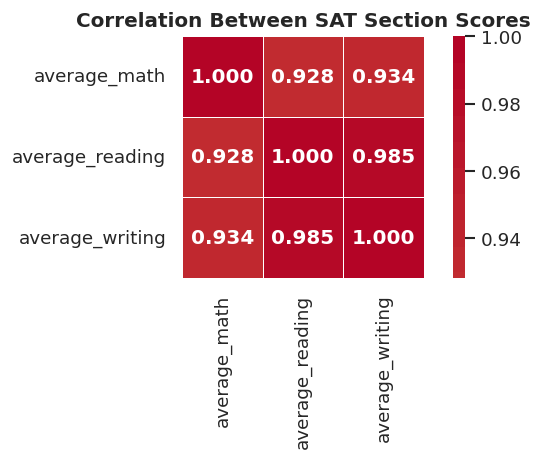


 Reading and Writing are highly correlated (>0.97) — students who read well tend to write well.
   Math correlates more loosely, suggesting a distinct skill profile.


In [17]:
# --- Bonus 1: Correlation between Math, Reading, and Writing ---
score_cols = ['average_math', 'average_reading', 'average_writing']
corr = schools[score_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Correlation Between SAT Section Scores', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\n Reading and Writing are highly correlated (>0.97) — students who read well tend to write well.')
print('   Math correlates more loosely, suggesting a distinct skill profile.')

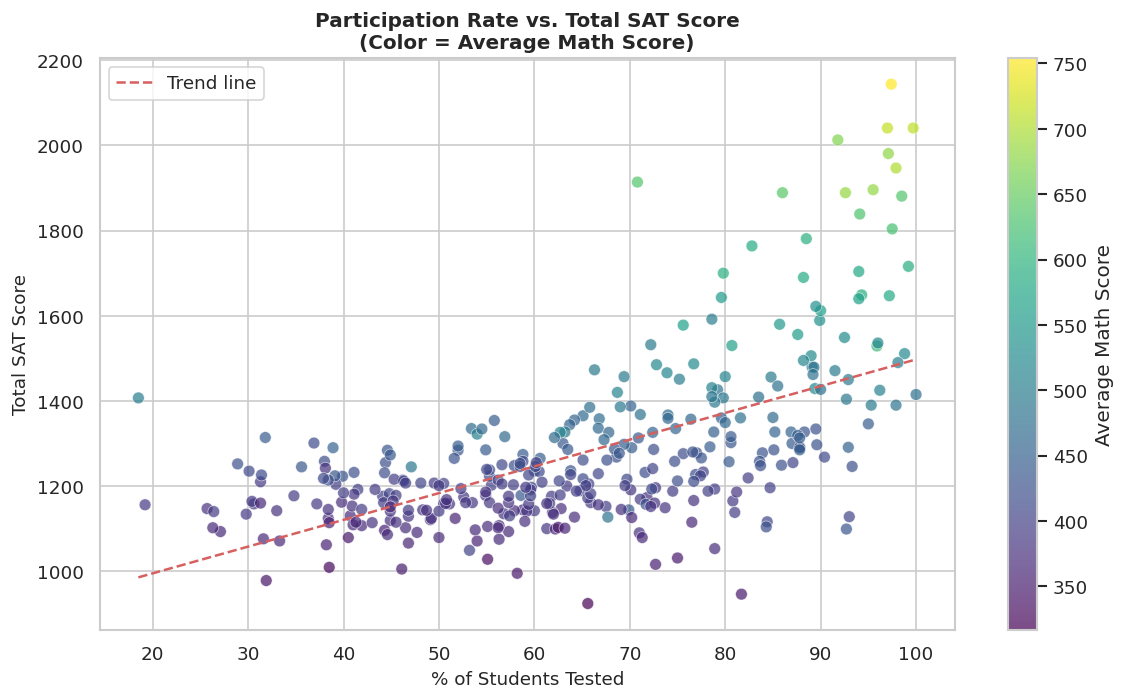


 Interesting pattern: schools with 80-100% participation tend to cluster in the
   middle SAT range. The very highest scorers often have below 100% participation,
   possibly because not all students at those schools take the SAT.


In [18]:
# --- Bonus 2: SAT Participation Rate vs. Total SAT Score ---
schools_tested = schools.dropna(subset=['percent_tested']).copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    schools_tested['percent_tested'],
    schools_tested['total_SAT'],
    c=schools_tested['average_math'],
    cmap='viridis', alpha=0.7, s=50, edgecolors='white', linewidth=0.4
)
plt.colorbar(scatter, ax=ax, label='Average Math Score')

ax.set_xlabel('% of Students Tested', fontsize=11)
ax.set_ylabel('Total SAT Score', fontsize=11)
ax.set_title('Participation Rate vs. Total SAT Score\n(Color = Average Math Score)',
             fontsize=12, fontweight='bold')

# Trend line
z = np.polyfit(schools_tested['percent_tested'], schools_tested['total_SAT'], 1)
p = np.poly1d(z)
x_line = np.linspace(schools_tested['percent_tested'].min(),
                     schools_tested['percent_tested'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend line')
ax.legend()
plt.tight_layout()
plt.show()

print('\n Interesting pattern: schools with 80-100% participation tend to cluster in the')
print('   middle SAT range. The very highest scorers often have below 100% participation,')
print('   possibly because not all students at those schools take the SAT.')

/tmp/ipykernel_3506/1128782995.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


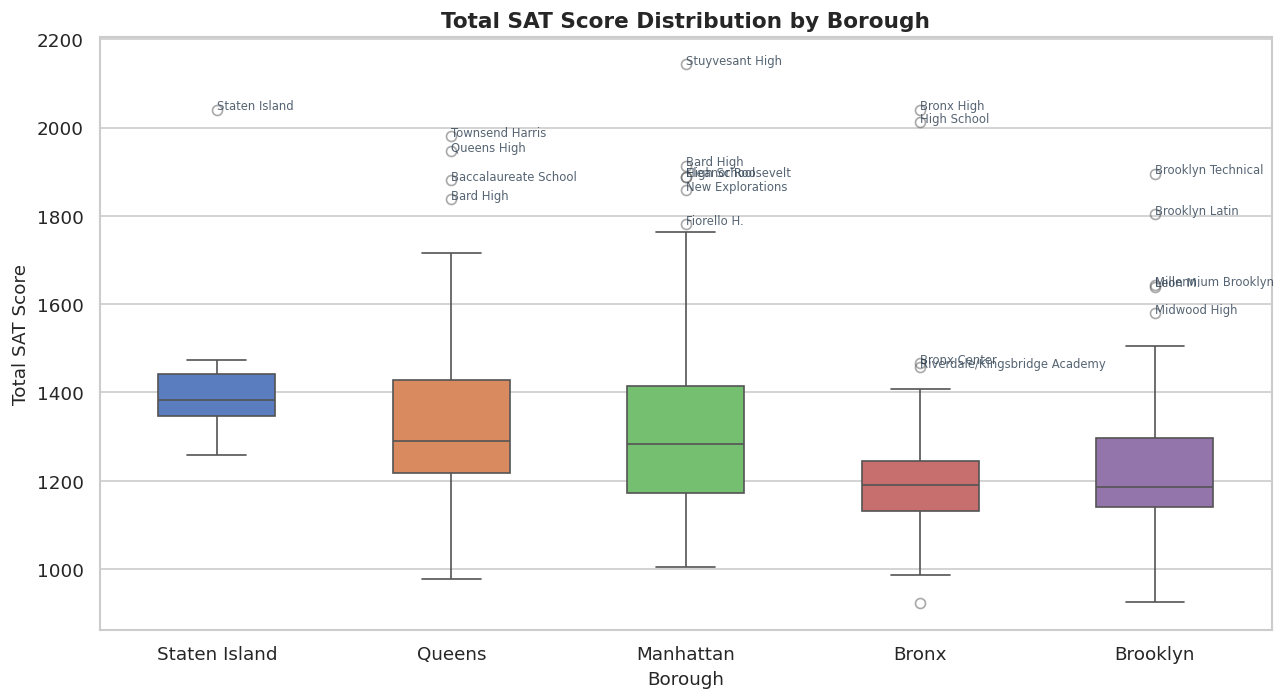


 Each borough has its own story:
   • Manhattan: widest spread — most unequal
   • Staten Island: fewest schools, tighter cluster
   • Bronx: lowest median but has notable outliers (Bronx Science)


In [20]:
# --- Bonus 3: Score distribution within each borough (Box plot) ---
borough_order = schools.groupby('borough')['total_SAT'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=schools, x='borough', y='total_SAT',
    order=borough_order, palette='muted',
    width=0.5, flierprops={'marker': 'o', 'alpha': 0.5}, ax=ax
)

ax.set_title('Total SAT Score Distribution by Borough', fontsize=13, fontweight='bold')
ax.set_xlabel('Borough', fontsize=11)
ax.set_ylabel('Total SAT Score', fontsize=11)

# Annotate outliers with school name
for borough in borough_order:
    subset = schools[schools['borough'] == borough]
    q1 = subset['total_SAT'].quantile(0.25)
    q3 = subset['total_SAT'].quantile(0.75)
    iqr = q3 - q1
    outliers = subset[subset['total_SAT'] > q3 + 1.5 * iqr]
    for _, row in outliers.iterrows():
        short_name = row['school_name'].split(' ')[0:2]
        ax.annotate(' '.join(short_name),
                    xy=(list(borough_order).index(borough), row['total_SAT']),
                    fontsize=7, alpha=0.8, color='#2c3e50')

plt.tight_layout()
plt.show()

print('\n Each borough has its own story:')
print('   • Manhattan: widest spread — most unequal')
print('   • Staten Island: fewest schools, tighter cluster')
print('   • Bronx: lowest median but has notable outliers (Bronx Science)')

In [21]:
# --- Bonus 4: Bottom 10 schools (often overlooked but important) ---
bottom_10 = (
    schools.sort_values('total_SAT')
    [['school_name', 'borough', 'total_SAT']]
    .head(10)
    .reset_index(drop=True)
)
bottom_10.index += 1

print(' Bottom 10 Schools by Total SAT Score')
print('(These schools likely face greater resource challenges and deserve support)')
print()
bottom_10

 Bottom 10 Schools by Total SAT Score
(These schools likely face greater resource challenges and deserve support)



,school_name,borough,total_SAT
1,Pan American International High School at Monroe,Bronx,924
2,Multicultural High School,Brooklyn,926
3,International High School at Prospect Heights,Brooklyn,946
4,Pan American International High School,Queens,978
5,Kingsbridge International High School,Bronx,987
6,International Community High School,Bronx,995
7,Bronx International High School,Bronx,1005
8,Manhattan Academy for Arts and Language,Manhattan,1005
9,W. H. Maxwell Career and Technical Education High School,Brooklyn,1009
10,High School of Language and Innovation,Bronx,1016


---

##  Step 7: Summary of Findings

###  Task Answers

| Task | Answer |
|------|--------|
| Best math schools (≥ 640) | **10 schools** qualify; Stuyvesant leads with **754** |
| Top overall school | **Stuyvesant High School** (2,144 total SAT) |
| Borough with highest variability | **Manhattan** (std_SAT ≈ 230+) |

---

###  Key Insights

1. **Specialized schools dominate the top** — Stuyvesant, Bronx Science, Brooklyn Tech, and Staten Island Tech all require competitive entrance exams. This raises questions about equity and access.

2. **Manhattan is the most unequal borough** — it contains both the highest and some of the lowest scoring schools in the city. The standard deviation reflects this wide spread.

3. **Reading and Writing are almost perfectly correlated** — suggesting that literacy-focused interventions could simultaneously raise both scores.

4. **Participation rate does not predict high performance** — several schools with near-100% participation rate score near the citywide average, while some high-scoring schools have lower participation.

5. **The gap between top and bottom is striking** — the top school (Stuyvesant) scores over **800 points more** than the lowest-performing schools, all within the same public school system.

---

### Reflection

This data tells a story about **educational inequality** in one of the world's most famous cities. Raw test scores are shaped by many factors outside schools' control — neighborhood resources, family income, language background, and access to test prep. The data is a starting point for deeper questions, not a final verdict on any school.

---

* This notebook is part of my DataCamp Portfolio — expanded and published on GitHub.  
*🔗 GitHub: [xqrnz](https://github.com/xqrnz)*